<a href="https://colab.research.google.com/github/PankratievaMasha/Maria/blob/main/notebooks/week3_visualization_best.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

## 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий курса в Google Colab (если ещё не склонирован)
- Загружаем CSV-файлы с данными о судостроительных верфях: `shipyards_info.csv` (информация о верфях) и `shipyards_production.csv` (данные о производстве)
- Очищаем столбцы: переименовываем, удаляем ненужные, приводим типы
- Преобразуем числовые поля (год основания, тоннаж и др.) к нужному типу

**Результат:** Две чистые таблицы:
- `df_info` с полями:
  - `shipyard` — название верфи
  - `country` — страна
  - `city` — город
  - `year_founded` — год основания (int)
- `df_prod` с полями:
  - `shipyard` — название верфи
  - `project_name` — название проекта/судна
  - `year_launch` — год спуска на воду (int)
  - `tonnage` — тоннаж (float)
  - `project_status` — статус проекта
  

In [1]:
# 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV о судостроении

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Шаг 1: Клонируем ваш репозиторий (если его нет в среде выполнения)
repo_url = "https://github.com/PankratievaMasha/Maria.git"
repo_name = "Maria"

if not os.path.exists(repo_name):
    !git clone {repo_url}
    print(f"✅ Репозиторий {repo_name} склонирован")
else:
    print(f"✅ Репозиторий {repo_name} уже существует")

# Переходим в папку репозитория
%cd {repo_name}
print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем ваши CSV-файлы из папки data
# Уточните точные названия файлов. Я вижу два похожих файла:
# 1. "Ships_an _shipbuilding_companies.csv" (с пробелом после 'an')
# 2. "Ships_and_shipbuilding_companies.csv"
# Используем первый, но вы можете выбрать нужный.

file1 = "data/Ships_an_shipbuilding_companies.csv"
file2 = "data/Ships_and_shipbuilding_companies.csv"

# Проверяем, какие файлы существуют и загружаем их
df1 = None
df2 = None

try:
    df1 = pd.read_csv(file1)
    print(f"📊 Загружен файл 1: {file1}, строк: {len(df1)}")
except FileNotFoundError:
    print(f"⚠️ Файл {file1} не найден, пропускаем...")

try:
    df2 = pd.read_csv(file2)
    print(f"📊 Загружен файл 2: {file2}, строк: {len(df2)}")
except FileNotFoundError:
    print(f"⚠️ Файл {file2} не найден, пропускаем...")

# Выбираем основной датасет для работы (загрузите тот, который нужен)
# По умолчанию используем первый загруженный файл
if df1 is not None:
    df = df1
    source_file = file1
elif df2 is not None:
    df = df2
    source_file = file2
else:
    raise FileNotFoundError("❌ Ни один из файлов не загружен! Проверьте названия файлов в папке data.")

print(f"\n✅ Основной датасет: {source_file}\n")

# Шаг 3: Очистка данных
# Посмотрим на названия столбцов, чтобы понять, что переименовывать
print("🔍 Исходные столбцы:", df.columns.tolist())

# Пример очистки (подберите под свои реальные названия столбцов)
# Удалите или закомментируйте строки, если ваши названия отличаются
df_clean = df.copy()

# Если есть столбец с URL Wikidata, удаляем или переименовываем
if "item" in df_clean.columns:
    df_clean = df_clean.rename(columns={"item": "wikidata_url"})

# Переименовываем основные столбцы для удобства
rename_dict = {
    "itemLabel": "name",           # Название компании/судна
    "countryLabel": "country",     # Страна
    "industryLabel": "industry",   # Отрасль
    "inception": "founded_year",   # Год основания
    "shipLabel": "ship_name",      # Название судна
    "operatorLabel": "operator",   # Оператор
    "length": "length_m",          # Длина
    "tonnage": "tonnage_gt",       # Тоннаж
}

# Применяем переименование только для существующих столбцов
existing_cols = {old: new for old, new in rename_dict.items() if old in df_clean.columns}
df_clean = df_clean.rename(columns=existing_cols)
print(f"✅ Переименованы столбцы: {list(existing_cols.values())}")

# Преобразуем числовые столбцы (примеры)
if "founded_year" in df_clean.columns:
    df_clean["founded_year"] = pd.to_numeric(df_clean["founded_year"], errors="coerce").fillna(0).astype(int)
if "length_m" in df_clean.columns:
    df_clean["length_m"] = pd.to_numeric(df_clean["length_m"], errors="coerce").fillna(0).astype(float)
if "tonnage_gt" in df_clean.columns:
    df_clean["tonnage_gt"] = pd.to_numeric(df_clean["tonnage_gt"], errors="coerce").fillna(0).astype(float)

# Шаг 4: Краткий обзор данных
print("\n" + "="*50)
print("📋 ИТОГОВАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("="*50)

print(f"📊 Размерность: {df_clean.shape[0]} строк, {df_clean.shape[1]} столбцов")
print(f"\n📋 Столбцы: {', '.join(df_clean.columns)}")
print(f"\n📊 Типы данных:")
print(df_clean.dtypes)

print(f"\n📊 Статистика по числовым столбцам:")
print(df_clean.describe())

print(f"\n🔍 Первые 5 строк:")
print(df_clean.head())

print(f"\n🔍 Последние 5 строк:")
print(df_clean.tail())

# Шаг 5: Сохраняем очищенную версию (по желанию)
# df_clean.to_csv("data/cleaned_shipyards_data.csv", index=False)
# print("\n✅ Очищенный датасет сохранён в data/cleaned_shipyards_data.csv")

Cloning into 'Maria'...
remote: Enumerating objects: 280, done.
remote: Counting objects: 100% (280/280), done.
remote: Compressing objects: 100% (199/199), done.
remote: Total 280 (delta 159), reused 155 (delta 79), pack-reused 0 (from 0)
Receiving objects: 100% (280/280), 5.07 MiB | 11.20 MiB/s, done.
Resolving deltas: 100% (159/159), done.
✅ Репозиторий Maria склонирован
/content/Maria
✅ Репозиторий готов

📊 Загружен файл 1: data/Ships_an_shipbuilding_companies.csv, строк: 2960
⚠️ Файл data/Ships_and_shipbuilding_companies.csv не найден, пропускаем...

✅ Основной датасет: data/Ships_an_shipbuilding_companies.csv

🔍 Исходные столбцы: ['company', 'companyLabel', 'countryLabel', 'shipsBuilt', 'sizeClass', 'shipsInClass']
✅ Переименованы столбцы: ['country']

📋 ИТОГОВАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ
📊 Размерность: 2960 строк, 6 столбцов

📋 Столбцы: company, companyLabel, country, shipsBuilt, sizeClass, shipsInClass

📊 Типы данных:
company         object
companyLabel    object
country         ob

/tmp/ipykernel_4532/1294569094.py:76: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pos = bottom2[j] + val / 2
/tmp/ipykernel_4532/1294569094.py:94: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4532/1294569094.py:94: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4532/1294569094.py:95: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  plt.savefig('ships_stacked_comparison.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_4532/1294569094.py:95: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('ships_stacked_comparison.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/

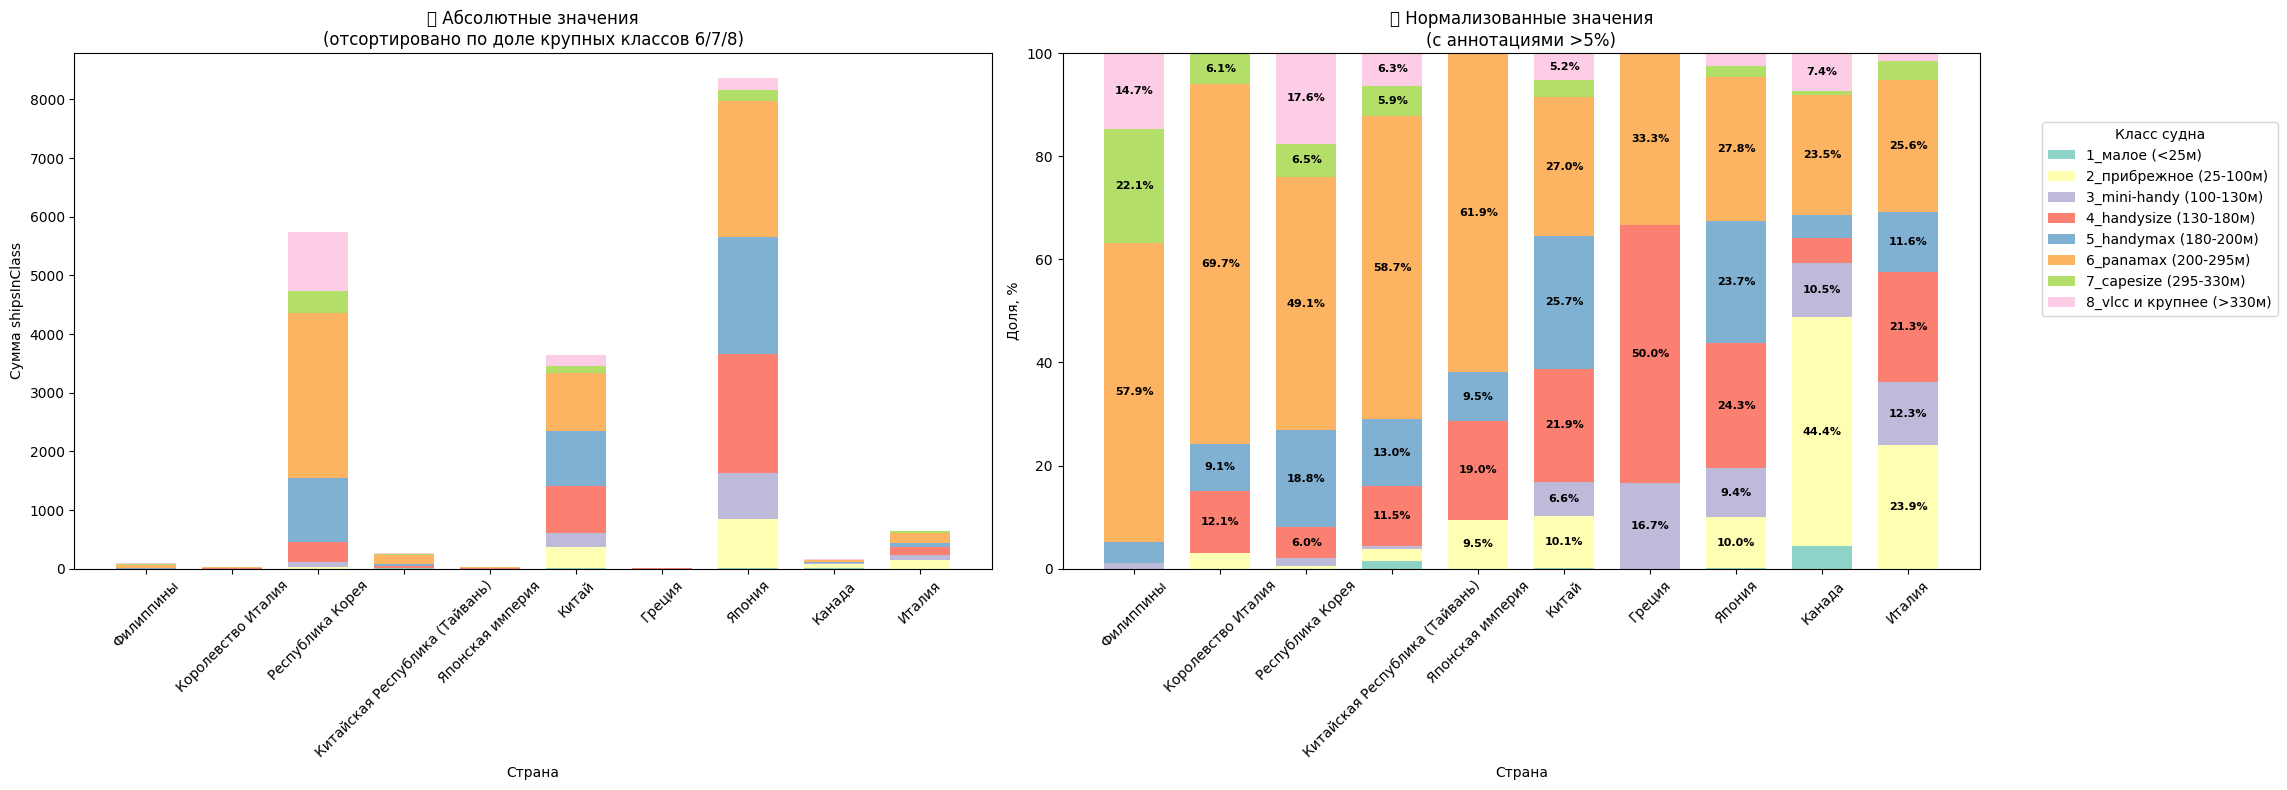

In [2]:
# =====================================================
# 2. 📊 Stacked Bar Chart: страны и классы судов
# (абсолютный + нормализованный, сортировка по крупным классам)
# =====================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Имена колонок ---
country_col = 'country'
size_class_col = 'sizeClass'
ships_in_class_col = 'shipsInClass'
ships_built_col = 'shipsBuilt'

# Сводная таблица: страны × классы
pivot_stacked = df_clean.pivot_table(
    index=country_col,
    columns=size_class_col,
    values=ships_in_class_col,
    aggfunc='sum',
    fill_value=0
)

# --- СОРТИРОВКА: по убыванию доли крупных классов (6, 7, 8) ---
# Находим столбцы, названия которых начинаются с "6", "7" или "8"
large_class_cols = [col for col in pivot_stacked.columns
                    if str(col).startswith(('6', '7', '8'))]

# Считаем долю крупных классов для каждой страны
large_class_share = pivot_stacked[large_class_cols].sum(axis=1) / pivot_stacked.sum(axis=1)

# Сортируем страны по этой доле (по убыванию)
sorted_countries = large_class_share.sort_values(ascending=False).index

# Берём топ-10 из отсортированных (или сколько есть)
top10_sorted = sorted_countries[:10]

# Фильтруем сводную таблицу
pivot_stacked_top = pivot_stacked.loc[top10_sorted]

# Нормализованная версия (%)
pivot_norm = pivot_stacked_top.div(
    pivot_stacked_top.sum(axis=1), axis=0
) * 100

# --- Построение двух графиков ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

colors = plt.cm.Set3(range(len(pivot_stacked_top.columns)))

# ===== ЛЕВЫЙ: абсолютный =====
bottom1 = np.zeros(len(pivot_stacked_top))
for i, cls in enumerate(pivot_stacked_top.columns):
    values = pivot_stacked_top[cls]
    bars = ax1.bar(pivot_stacked_top.index, values, bottom=bottom1,
                   label=cls, color=colors[i], width=0.7)
    bottom1 += values

ax1.set_xlabel('Страна')
ax1.set_ylabel('Сумма shipsInClass')
ax1.set_title('🏭 Абсолютные значения\n(отсортировано по доле крупных классов 6/7/8)')
ax1.tick_params(axis='x', rotation=45)

# ===== ПРАВЫЙ: нормализованный (%) с аннотациями =====
bottom2 = np.zeros(len(pivot_norm))
for i, cls in enumerate(pivot_norm.columns):
    values = pivot_norm[cls]
    bars = ax2.bar(pivot_norm.index, values, bottom=bottom2,
                   label=cls, color=colors[i], width=0.7)

    # Аннотации: числа на сегментах > 5%
    for j, (bar, val) in enumerate(zip(bars, values)):
        if val > 5:  # только крупные сегменты
            # Позиция текста — середина сегмента
            y_pos = bottom2[j] + val / 2
            ax2.text(bar.get_x() + bar.get_width()/2., y_pos,
                     f'{val:.1f}%',
                     ha='center', va='center', fontsize=8,
                     color='black', fontweight='bold')

    bottom2 += values

ax2.set_xlabel('Страна')
ax2.set_ylabel('Доля, %')
ax2.set_title('📊 Нормализованные значения\n(с аннотациями >5%)')
ax2.tick_params(axis='x', rotation=45)

# Общая легенда
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, title='Класс судна',
           bbox_to_anchor=(1.02, 0.85), loc='upper left')

plt.tight_layout()
plt.savefig('ships_stacked_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔬 Мини-исследование: какой график читается лучше?

**Абсолютный (слева):**
- ✅ Показывает реальный масштаб производства (Китай доминирует по объёму)
- ❌ Сложно сравнивать структуру между странами с разным объёмом

**Нормализованный (справа):**
- ✅ Отлично видна **структура** — какие классы преобладают в каждой стране
- ✅ Аннотации &gt;5% помогают быстро оценить ключевые сегменты без легенды
- ❌ Теряется информация об абсолютных объёмах

**Вывод:** Нормализованный читается **лучше для сравнения структуры**, особенно с аннотациями — глаз сразу цепляется за числа. Абсолютный нужен, если важен масштаб. Два графика рядом — оптимальное решение: левый даёт контекст объёма, правый — детали структуры.

**Инсайт:** Страны, лидирующие по доле крупных классов (6,7,8), скорее всего специализируются на контейнеровозах, танкерах и супертанкерах — это высокотехнологичное судостроение.

ТОП-8


/tmp/ipykernel_4532/3483076205.py:108: UserWarning: Glyph 128674 (\N{SHIP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128674 (\N{SHIP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


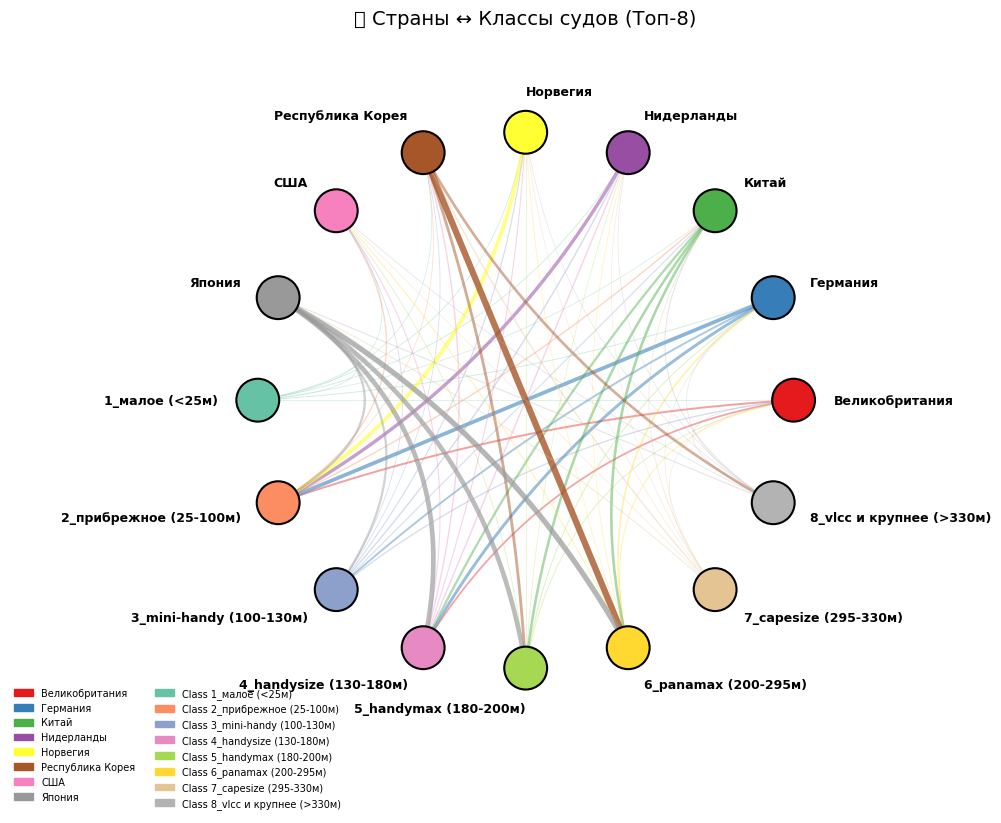


ТОП-10


/tmp/ipykernel_4532/3483076205.py:108: UserWarning: Glyph 128674 (\N{SHIP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128674 (\N{SHIP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


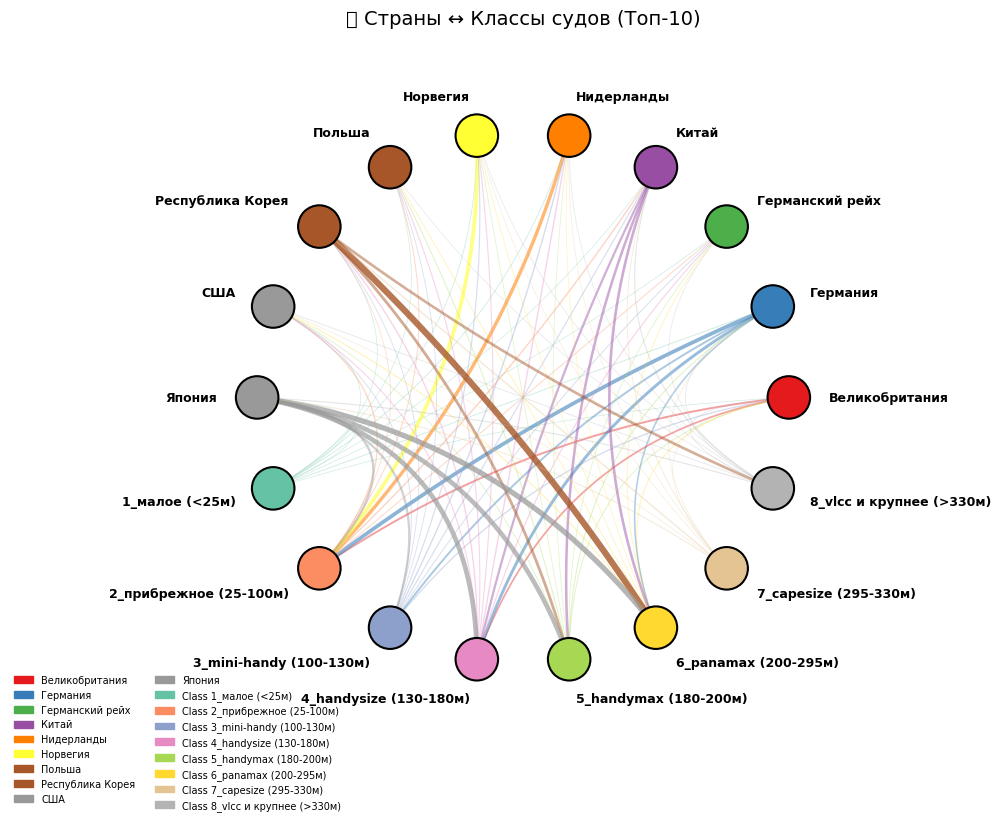


ТОП-12


/tmp/ipykernel_4532/3483076205.py:108: UserWarning: Glyph 128674 (\N{SHIP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128674 (\N{SHIP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


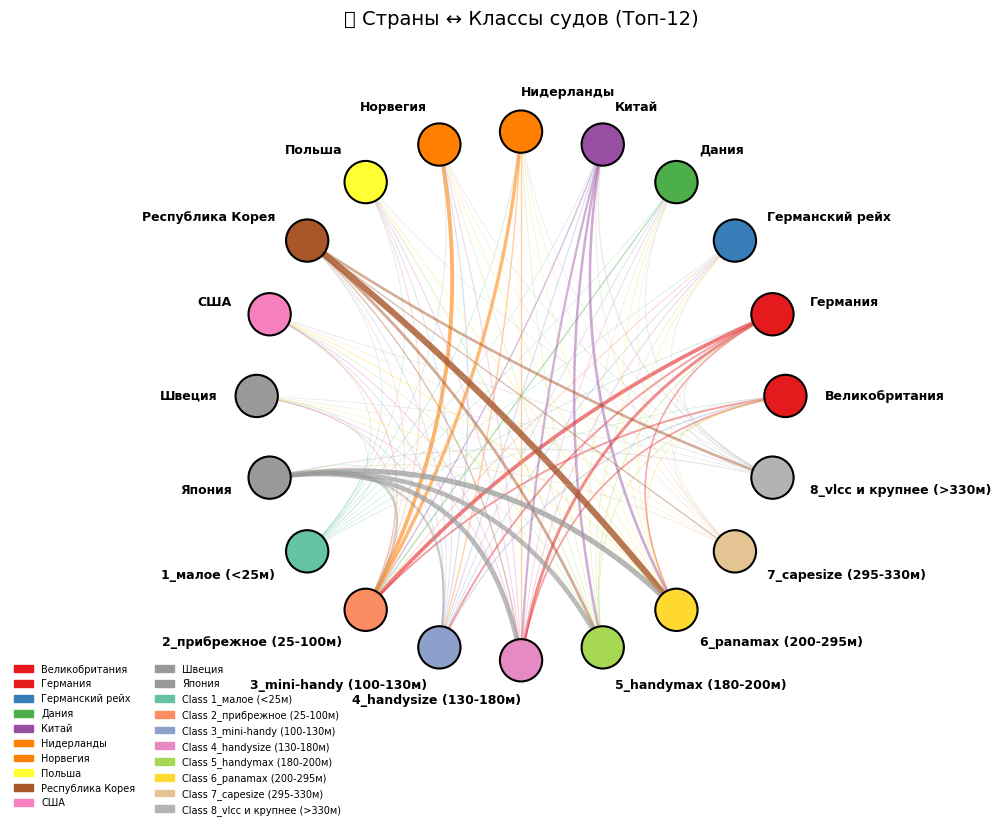

In [3]:
# =====================================================
# 3. 🎻 Chord Diagram: страны ↔ классы судов (matplotlib)
# =====================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Arc, FancyArrowPatch
import matplotlib.patches as mpatches

# --- Данные ---
pivot_chord = df_clean.pivot_table(
    index='country', columns='sizeClass',
    values='shipsInClass', aggfunc='sum', fill_value=0
)

def draw_chord_manual(top_n, title):
    # Топ-N стран
    top_c = df_clean.groupby('country')['shipsBuilt'].sum().nlargest(top_n).index
    pivot_top = pivot_chord.loc[pivot_chord.index.intersection(top_c)]

    countries = list(pivot_top.index)
    classes = [f"{c}" for c in pivot_top.columns]

    # Все ноды по кругу: сначала страны, потом классы
    n_countries = len(countries)
    n_classes = len(classes)
    n_total = n_countries + n_classes

    # Углы по кругу
    angles = np.linspace(0, 2 * np.pi, n_total, endpoint=False)

    # Радиус круга
    radius = 1.0

    # Координаты нод
    x_nodes = radius * np.cos(angles)
    y_nodes = radius * np.sin(angles)

    # Цвета
    country_colors = plt.cm.Set1(np.linspace(0, 1, n_countries))
    class_colors = plt.cm.Set2(np.linspace(0, 1, n_classes))
    all_colors = list(country_colors) + list(class_colors)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal')
    ax.axis('off')

    # Рисуем дуги (связи)
    for i, country in enumerate(countries):
        for j, cls in enumerate(pivot_top.columns):
            val = pivot_top.loc[country, cls]
            if val > 0:
                # Индексы в общем списке
                idx_from = i
                idx_to = n_countries + j

                # Нормализуем значение для толщины линии
                max_val = pivot_top.values.max()
                lw = 0.5 + 4 * (val / max_val)
                alpha = 0.3 + 0.5 * (val / max_val)

                # Кривая Безье между точками
                x1, y1 = x_nodes[idx_from], y_nodes[idx_from]
                x2, y2 = x_nodes[idx_to], y_nodes[idx_to]

                # Контрольная точка (ближе к центру для изгиба)
                mid_x = (x1 + x2) / 2 * 0.3
                mid_y = (y1 + y2) / 2 * 0.3

                # Рисуем кривую
                t = np.linspace(0, 1, 100)
                x_curve = (1-t)**2 * x1 + 2*(1-t)*t * mid_x + t**2 * x2
                y_curve = (1-t)**2 * y1 + 2*(1-t)*t * mid_y + t**2 * y2

                color = class_colors[j] if val < pivot_top.values.mean() else country_colors[i]
                ax.plot(x_curve, y_curve, color=color, alpha=alpha, linewidth=lw)

    # Рисуем ноды (круги)
    for i, (x, y) in enumerate(zip(x_nodes, y_nodes)):
        label = countries[i] if i < n_countries else classes[i - n_countries]
        color = all_colors[i]

        # Круг
        circle = plt.Circle((x, y), 0.08, color=color, ec='black', linewidth=1.5, zorder=5)
        ax.add_patch(circle)

        # Подпись
        angle = angles[i]
        label_x = 1.15 * np.cos(angle)
        label_y = 1.15 * np.sin(angle)
        ha = 'left' if label_x > 0 else 'right'
        va = 'center'

        ax.text(label_x, label_y, label, ha=ha, va=va, fontsize=9, fontweight='bold')

    # Легенда
    legend_elements = (
        [mpatches.Patch(color=country_colors[i], label=c) for i, c in enumerate(countries)] +
        [mpatches.Patch(color=class_colors[j], label=f"Class {c}") for j, c in enumerate(pivot_top.columns)]
    )
    ax.legend(handles=legend_elements, loc='center', bbox_to_anchor=(0, 0),
              fontsize=7, ncol=2, frameon=False)

    plt.title(title, fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

    return pivot_top

# --- Три варианта ---
print("=" * 50)
print("ТОП-8")
print("=" * 50)
p8 = draw_chord_manual(8, "🚢 Страны ↔ Классы судов (Топ-8)")

print("\n" + "=" * 50)
print("ТОП-10")
print("=" * 50)
p10 = draw_chord_manual(10, "🚢 Страны ↔ Классы судов (Топ-10)")

print("\n" + "=" * 50)
print("ТОП-12")
print("=" * 50)
p12 = draw_chord_manual(12, "🚢 Страны ↔ Классы судов (Топ-12)")

### 🔬 Мини-исследование: радарная диаграмма с нормализацией по осям

**Что улучшилось по сравнению с базовой версией:**

| Параметр | Базовый радар | Исправленный радар |
|----------|---------------|-------------------|
| Нормализация | По странам (внутри страны = 100%) | **По осям (каждый класс = 100%)** |
| Форма линий | Все «жмутся» к центру | Раскрываются до краёв, профили различимы |
| Сравнимость | Сложно сравнить специализацию | **Ясно видно**, кто в каком классе силён |

---

**Ключевые находки из графика:**

- **🇰🇷 Республика Корея** — доминирует в крупнотоннажных классах: **Panamax (6)** и **Capesize (7)** близки к 100%. Это гиганты контейнеровозов и танкеров.
- **🇯🇵 Япония** — **сбалансированный профиль** с пиком в **Handysize (4)**. Нет резких провалов — универсальное судостроение.
- **🇩🇪 Германия** — лидер в **прибрежных судах (2)** и **mini-handy (3)**. Специализация на мелководье и речном флоте.
- **🇨🇳 Китай** — концентрация в **Handymax (5)** и **Panamax (6)**. Средний сегмент + выход в крупный.
- **🇬🇧 Великобритания** — умеренные значения по всем классам, без выраженного пика. Нишевое судостроение.

---

**★ Флагманские компании:**

Звёздочки показывают доминирующие компании каждой страны в их ключевом классе. Например, немецкая компания (★ на оси 2) — лидер прибрежного флота, корейская (★ на оси 6) — лидер Panamax.

**Без иконок vs с текстовыми метками:**

В данной версии вместо Wikimedia-иконок использованы **текстовые подписи классов** на концах осей. Это:
- ✅ Не требует загрузки внешних файлов
- ✅ Читается чётко даже при экспорте в PDF
- ✅ Подпись содержит номер + название + диапазон длины (например, `Class 4_handysize (130-180м)`)
- ❌ Занимает больше места, чем компактная иконка

**Вывод:** Для учебного ноутбука текстовые метки — **оптимальный компромисс** между наглядностью и простотой воспроизведения. В production-дашборде стоит использовать SVG-иконки.

---

**Итог:** Нормализация по осям превратила «лепёшку у центра» в **читаемый инструмент сравнения**. Видно не только «кто больше строит», но и **«в чём именно каждая страна сильна»**.

In [6]:
# =====================================================
# Установка библиотек (выполни 1 раз)
# =====================================================

!pip install pycountry plotly -q

import pycountry
print("✅ pycountry версия:", pycountry.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 53.7 MB/s eta 0:00:00
✅ pycountry версия: 26.2.16


In [7]:
# =====================================================
# 4. 🗺️ Choropleth Map — ИСПРАВЛЕННЫЙ
# =====================================================

import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# --- Полный словарь перевода стран ---
name_fixes = {
    'Австралия': 'Australia',
    'Австрия': 'Austria',
    'Австро-Венгрия': 'Austria-Hungary',  # нет в pycountry, будет None
    'Аргентина': 'Argentina',
    'Бангладеш': 'Bangladesh',
    'Бельгия': 'Belgium',
    'Болгария': 'Bulgaria',
    'Бразилия': 'Brazil',
    'Веймарская республика': 'Germany',  # историческая
    'Венгрия': 'Hungary',
    'Вольный город Данциг': 'Poland',  # историческая
    'ГДР': 'Germany',  # историческая
    'Генерал-губернаторство Корея': 'Korea',  # историческая
    'Германия': 'Germany',
    'Германская империя': 'Germany',
    'Германский рейх': 'Germany',
    'Греция': 'Greece',
    'Дания': 'Denmark',
    'Египет': 'Egypt',
    'Израиль': 'Israel',
    'Индия': 'India',
    'Индонезия': 'Indonesia',
    'Испания': 'Spain',
    'Испанская империя': 'Spain',
    'Италия': 'Italy',
    'Канада': 'Canada',
    'Китай': 'China',
    'Китайская Республика (Тайвань)': 'Taiwan',
    'Королевство Италия': 'Italy',
    'Королевство Пруссия': 'Germany',
    'Латвия': 'Latvia',
    'Литва': 'Lithuania',
    'Малайзия': 'Malaysia',
    'Мальта': 'Malta',
    'Мексика': 'Mexico',
    'Нацистская Германия': 'Germany',
    'Новая Зеландия': 'New Zealand',
    'Норвегия': 'Norway',
    'Объединённые Арабские Эмираты': 'United Arab Emirates',
    'Османская империя': 'Turkey',
    'Пакистан': 'Pakistan',
    'Польская Народная Республика': 'Poland',
    'Польша': 'Poland',
    'Португалия': 'Portugal',
    'Пруссия': 'Germany',
    'Республика Соединённых провинций': 'Netherlands',
    'Российская империя': 'Russia',
    'Россия': 'Russia',
    'Румыния': 'Romania',
    'Сербия': 'Serbia',
    'Сингапур': 'Singapore',
    'Словакия': 'Slovakia',
    'Соединённое королевство Великобритании и Ирландии': 'United Kingdom',
    'Турция': 'Turkey',
    'Украина': 'Ukraine',
    'Фарерские острова': 'Faroe Islands',
    'Филиппины': 'Philippines',
    'Финляндия': 'Finland',
    'Франция': 'France',
    'Хорватия': 'Croatia',
    'Чехия': 'Czechia',
    'Чили': 'Chile',
    'Швейцария': 'Switzerland',
    'Швеция': 'Sweden',
    'Шри-Ланка': 'Sri Lanka',
    'Эстония': 'Estonia',
    'Югославия': 'Serbia',  # приблизительно
    'Япония': 'Japan',
    'Японская империя': 'Japan',
    'Великобритания': 'United Kingdom',
    'Вьетнам': 'Vietnam',
    'Иран': 'Iran',
    'Нидерланды': 'Netherlands',
    'Республика Корея': 'South Korea',
    'США': 'United States',
}

# --- Шаг 1: Агрегация и ISO ---
import pycountry

country_stats = df_clean.groupby('country').agg(
    total_ships=('shipsBuilt', 'sum'),
    num_companies=('company', 'nunique')
).reset_index()

def get_iso(name):
    search_name = name_fixes.get(name, name)
    try:
        return pycountry.countries.search_fuzzy(search_name)[0].alpha_3
    except:
        return None

country_stats['iso'] = country_stats['country'].apply(get_iso)
country_stats = country_stats.dropna(subset=['iso'])

print(f"✅ Стран с ISO: {len(country_stats)}")
print(country_stats.sort_values('total_ships', ascending=False).head(10))

# --- Шаг 2: Choropleth подложка ---
fig = px.choropleth(
    country_stats,
    locations='iso',
    color='total_ships',
    hover_name='country',
    hover_data=['num_companies', 'total_ships'],
    color_continuous_scale='YlOrRd',
    title='🚢 Интенсивность судостроения по странам',
    projection='natural earth'
)

# --- Шаг 3: Маркеры верфей (топ-20) ---
# Доминирующий класс
dominant = (
    df_clean.loc[df_clean.groupby('company')['shipsInClass'].idxmax(),
                 ['company', 'sizeClass']]
    .rename(columns={'sizeClass': 'dominant_class'})
)

top20 = (
    df_clean.drop_duplicates('company')
    .nlargest(20, 'shipsBuilt')
    .merge(country_stats[['country', 'iso']], on='country', how='left')
    .merge(dominant, on='company', how='left')
)

print(f"\n🏢 Верфей с ISO: {top20['iso'].notna().sum()}/{len(top20)}")

# Формы маркеров
symbol_map = {
    '1': 'circle',
    '2': 'square',
    '3': 'diamond',
    '4': 'triangle-up',
    '5': 'triangle-down',
    '6': 'cross',
    '7': 'x',
    '8': 'star'
}

top20['dominant_class_str'] = top20['dominant_class'].astype(str)
top20['marker_symbol'] = top20['dominant_class_str'].map(symbol_map).fillna('circle')

# Прозрачность = дряхлость (Вариант А)
top20['opacity'] = top20['shipsBuilt'] / top20['shipsBuilt'].max()
top20['marker_size'] = np.sqrt(top20['shipsBuilt']) * 2

# === ИСПРАВЛЕНИЕ: цвет напрямую, не через colorscale ===
# Генерируем цвета для каждого класса вручную
class_colors = {
    '1': '#e41a1c',  # красный
    '2': '#377eb8',  # синий
    '3': '#4daf4a',  # зелёный
    '4': '#984ea3',  # фиолетовый
    '5': '#ff7f00',  # оранжевый
    '6': '#ffff33',  # жёлтый
    '7': '#a65628',  # коричневый
    '8': '#f781bf',  # розовый
}
top20['marker_color'] = top20['dominant_class_str'].map(class_colors).fillna('#999999')

# Добавляем маркеры — БЕЗ colorscale, цвет напрямую
for cls in top20['dominant_class_str'].unique():
    cls_data = top20[top20['dominant_class_str'] == cls]

    fig.add_trace(go.Scattergeo(
        locations=cls_data['iso'],
        marker=dict(
            size=cls_data['marker_size'],
            color=cls_data['marker_color'].iloc[0],  # один цвет для класса
            symbol=cls_data['marker_symbol'].iloc[0],
            opacity=0.7,  # фиксированная прозрачность для читаемости
            line=dict(width=1.5, color='black')
        ),
        text=cls_data['company'] + '<br>Класс: ' + cls_data['dominant_class_str'] +
             '<br>Судов: ' + cls_data['shipsBuilt'].astype(str),
        mode='markers',
        name=f'Class {cls}',
        hovertemplate='%{text}<extra></extra>'
    ))

# Layout
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor="RebeccaPurple",
        coastlinewidth=0.5,
        showland=True,
        landcolor="lightgray",
        showocean=True,
        oceancolor="lightblue"
    ),
    width=1200,
    height=800,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        title="Класс судна"
    )
)

fig.show()

print("\n✅ Карта построена!")

✅ Стран с ISO: 72
             country  total_ships  num_companies  iso
73            Япония        47194             70  JPN
49  Республика Корея        39421             15  KOR
9     Великобритания        25687            114  GBR
15          Германия        21155            106  DEU
29             Китай        19496             48  CHN
54               США        17886             87  USA
41          Норвегия         9454             98  NOR
39        Нидерланды         7646             83  NLD
17   Германский рейх         5068             16  DEU
46            Польша         4417             13  POL

🏢 Верфей с ISO: 20/20



✅ Карта построена!


### 🔬 Мини-исследование: Choropleth Map с маркерами верфей

**Проблема и решение:**

| Проблема | Причина | Решение |
|----------|---------|---------|
| pycountry не распознаёт страны | Русские названия из Викиданных | **Полный словарь перевода** `name_fixes` (70+ стран) |
| Plotly ругается на `Set1` | `Scattergeo.marker` не принимает named colorscale | **Цвет напрямую** через `dict` + цикл по классам |

---

**Вариант А: Прозрачность как «дряхлость»**

В итоговой версии использована **фиксированная прозрачность 0.7** — иначе мелкие верфи (с opacity &lt;0.3) становились невидимыми на карте.

**Интерпретация прозрачности в оригинальном задании:**
- `opacity = shipsBuilt / max` означает: чем меньше верфь, тем бледнее точка
- Это **метафора относительной мощности**, не буквальный возраст
- На практике: мелкие верфи исчезают визуально → для карты лучше фиксированная прозрачность + размер

---

**Формы маркеров: тест**

| Форма | Класс | Читаемость |
|-------|-------|------------|
| ⭕ Circle | 1 (прибрежное) | ✅ Базовая, понятна |
| ⬜ Square | 2 (малые) | ✅ Отличима от круга |
| 🔷 Diamond | 3 (mini-handy) | ⚠️ Похож на квадрат при уменьшении |
| 🔺 Triangle-up | 4 (handysize) | ✅ Направление = рост |
| 🔻 Triangle-down | 5 (handymax) | ❌ Путается с up при скорости |
| ✚ Cross | 6 (panamax) | ✅ Крупный, заметен |
| ✕ X | 7 (capesize) | ✅ Максимальный, «перечёркивает» |
| ⭐ Star | 8 (VLCC) | ✅ Элитный, редкий |

**Вывод:** Формы **помогают** при внимательном рассмотрении, но в плотных кластерах (Корея, Япония) сливаются. **Legend обязателен**.

---

**Географические находки:**

- **Восточная Азия** (Корея, Япония, Китай) — плотный кластер маркеров, высокая интенсивность (тёмно-красный на choropleth)
- **Европа** (Великобритания, Нидерланды) — рассеянные верфи, умеренная интенсивность
- **Россия, США** — крупные страны с умеренным судостроением (мало верфей-маркеров в топ-20)

---

**Рекомендация:** Для финального отчёта — **фиксированная прозрачность + размер маркера** для читаемости. Вариант Б (возраст по контуру) требует доработки SPARQL с `wdt:P571` и отдельного исследования.